# Visual Question Answering on SHAPES Dataset
The SHAPES dataset consists of 30×30 RGB images containing simple geometric
shapes (circles, squares, triangles) in three colours (red, green, blue),
arranged on a 3×3 grid. Each image is paired with a compositional query
expressed in a parenthesised notation (e.g. `(is blue (left_of red))`)
and a boolean answer. Our goal is to predict the correct answer for unseen images
and queries.

---
## Section 1 — Setup

In [47]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
import os

np.random.seed(43)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


In [48]:
# Constants
SHAPES = ['circle', 'square', 'triangle']
COLORS = ['red', 'green', 'blue']
SIZES  = ['tiny', 'small', 'med', 'large']

SHAPE_TO_IDX = {s: i for i, s in enumerate(SHAPES)}
COLOR_TO_IDX = {c: i for i, c in enumerate(COLORS)}

print(f"Shapes: {SHAPES}")
print(f"Colors: {COLORS}")
print(f"Sizes:  {SIZES}")

Shapes: ['circle', 'square', 'triangle']
Colors: ['red', 'green', 'blue']
Sizes:  ['tiny', 'small', 'med', 'large']


In [49]:
# helpers for data loading
def load_split(size):
    images = np.load(f'train.{size}.input.npy')
    with open(f'train.{size}.query') as f:
        queries = [l.strip() for l in f]
    # The large split has a differently-named output file
    out_path = f'train.{size}.output' if os.path.exists(f'train.{size}.output') else f'train.{size}.output'
    with open(out_path) as f:
        labels = [l.strip() == 'true' for l in f]
    return images, queries, labels


def load_test():
    images = np.load('test.input.npy')
    with open('test.query') as f:
        queries = [l.strip() for l in f]
    with open('test.output') as f:
        labels = [l.strip() == 'true' for l in f]
    return images, queries, labels

for sz in SIZES:
    imgs, qs, ls = load_split(sz)
    print(f"  {sz:>6}: {len(imgs):>6} images, {len(qs):>6} queries, {len(ls):>6} labels")
test_images, test_queries, test_labels = load_test()
print(f"  {'test':>6}: {len(test_images):>6} images, {len(test_queries):>6} queries, {len(test_labels):>6} labels")

    tiny:     64 images,     64 queries,     64 labels
   small:    640 images,    640 queries,    640 labels
     med:   6400 images,   6400 queries,   6400 labels
   large:  13568 images,  13568 queries,  13568 labels
    test:   1024 images,   1024 queries,   1024 labels


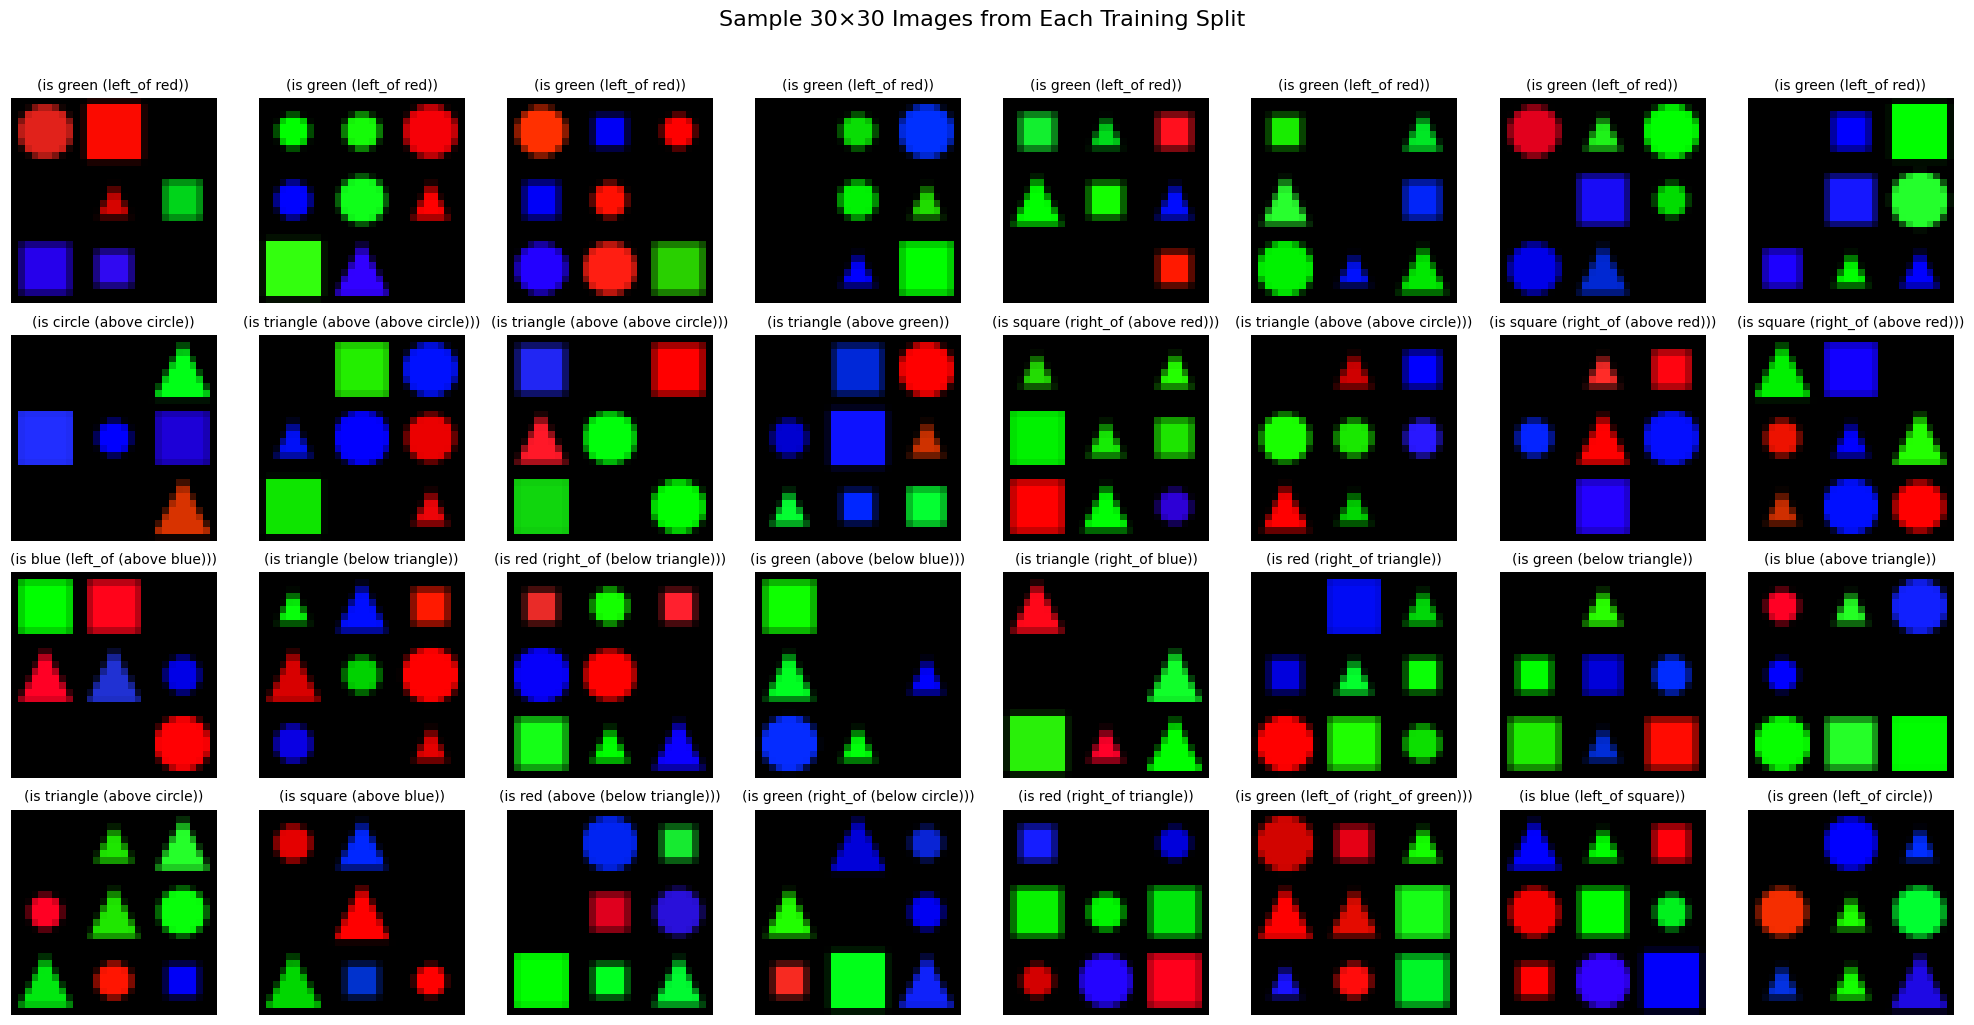

In [50]:
# Sample images
fig, axes = plt.subplots(len(SIZES), 8, figsize=(20, 10))
for row, sz in enumerate(SIZES):
    imgs, queries, _ = load_split(sz)
    idxs = np.random.choice(len(imgs), 8, replace=False)
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(imgs[idx])
        axes[row, col].set_title(queries[idx], fontsize=10)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(sz, fontsize=14, rotation=0, labelpad=50)
fig.suptitle('Sample 30×30 Images from Each Training Split', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2 — Baseline Approach

Our first instinct was to treat this as a standard deep-learning problem: 
encode the image, encode the text and fuse them to learn the answer directly.

- **Image encoder**: a small CNN that produces a 128-d vector
- **Text encoder**: bag-of-words over the query vocabulary -> 64-d vector
- **Fusion MLP**: concatenate both vectors -> two linear layers -> binary prediction

In [51]:
# Building vocabulary
train_imgs_large, train_queries_large, train_labels_large = load_split('large')

def build_vocab(queries):
    tokens = set()
    for q in queries:
        for ch in q:
            if ch in '()':
                tokens.add(ch)
        for tok in q.replace('(', ' ').replace(')', ' ').split():
            tokens.add(tok)
    vocab = {t: i for i, t in enumerate(sorted(tokens))}
    return vocab

vocab = build_vocab(train_queries_large + test_queries)
print(f"Vocabulary size: {len(vocab)}")
print(f"Tokens: {sorted(vocab.keys())}")

Vocabulary size: 13
Tokens: ['(', ')', 'above', 'below', 'blue', 'circle', 'green', 'is', 'left_of', 'red', 'right_of', 'square', 'triangle']


In [52]:
class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1) #(B, 128)


class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

    def forward(self, tokens):
        emb = self.embedding(tokens)        # (B, L, D)
        return emb.mean(dim=1)              # (B, D)


class VQA(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.img_enc = ImageEncoder()
        self.txt_enc = TextEncoder(vocab_size)
        self.classifier = nn.Sequential(
            nn.Linear(in_features=128 + 64, out_features=64), nn.ReLU(),
            nn.Linear(in_features=64, out_features=1),
        )

    def forward(self, img, tokens):
        iv = self.img_enc(img)
        tv = self.txt_enc(tokens)
        return self.classifier(torch.cat([iv, tv], dim=1)).squeeze(-1)


print("Model architecture:")
print(VQA(len(vocab)))

Model architecture:
VQA(
  (img_enc): ImageEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): AdaptiveAvgPool2d(output_size=1)
    )
  )
  (txt_enc): TextEncoder(
    (embedding): Embedding(13, 64)
  )
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [53]:
# Dataset and training
class VQADataset(Dataset):
    def __init__(self, images, queries, labels, vocab, max_len=20):
        self.images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.vocab = vocab
        self.max_len = max_len
        self.tokens = []
        for q in queries:
            toks = q.replace('(', ' ( ').replace(')', ' ) ').split()
            ids = [vocab[t] for t in toks if t in vocab]
            if len(ids) < max_len:
                ids += [0] * (max_len - len(ids))   # padding
            else:
                ids = ids[:max_len]

            self.tokens.append(ids)

        self.tokens = torch.tensor(self.tokens, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.tokens[idx], self.labels[idx]


train_ds = VQADataset(train_imgs_large, train_queries_large, train_labels_large, vocab)
test_ds  = VQADataset(test_images, test_queries, test_labels, vocab)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256)

baseline_model = VQA(len(vocab)).to(DEVICE)
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

baseline_losses = []
baseline_test_accs = []

for epoch in range(1, 21):
    baseline_model.train()
    total_loss = 0
    n_samples = 0
    for imgs, tokens, labs in train_loader:
        imgs, tokens, labs = imgs.to(DEVICE), tokens.to(DEVICE), labs.to(DEVICE)
        logits = baseline_model(imgs, tokens)
        loss = criterion(logits, labs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)
    avg_loss = total_loss / n_samples
    baseline_losses.append(avg_loss)

    # Test accuracy
    baseline_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, tokens, labs in test_loader:
            imgs, tokens, labs = imgs.to(DEVICE), tokens.to(DEVICE), labs.to(DEVICE)
            preds = (torch.sigmoid(baseline_model(imgs, tokens)) > 0.5).float()
            correct += (preds == labs).sum().item()
            total += labs.size(0)
    test_acc = correct / total
    baseline_test_accs.append(test_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>2}/20  Loss {avg_loss:.4f}  Test Acc {test_acc:.4f}")

  Epoch  1/20  Loss 0.6611  Test Acc 0.4404
  Epoch  5/20  Loss 0.6366  Test Acc 0.4238
  Epoch 10/20  Loss 0.6346  Test Acc 0.4170
  Epoch 15/20  Loss 0.6337  Test Acc 0.4307
  Epoch 20/20  Loss 0.6339  Test Acc 0.4326


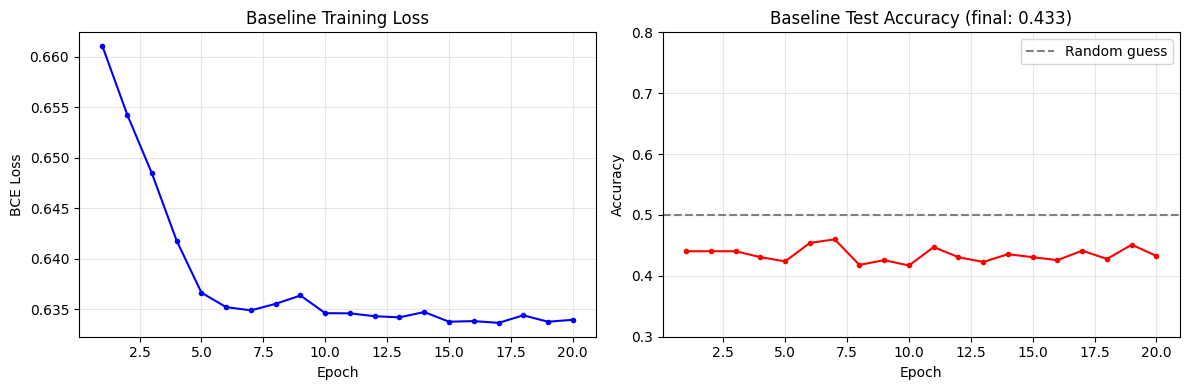


Final test accuracy: 0.4326 (443/1024)


In [54]:
# Loss and accuracy plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 21), baseline_losses, 'b-o', markersize=3)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Baseline Training Loss'); ax1.grid(True, alpha=0.3)

ax2.plot(range(1, 21), baseline_test_accs, 'r-o', markersize=3)
ax2.axhline(0.5, color='gray', ls='--', label='Random guess')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'Baseline Test Accuracy (final: {baseline_test_accs[-1]:.3f})')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(0.3, 0.8)

plt.tight_layout()
plt.show()
print(f"\nFinal test accuracy: {baseline_test_accs[-1]:.4f} ({int(baseline_test_accs[-1]*1024)}/1024)")

### Why the Baseline Fails

The end-to-end neural model hovers around **55–65% accuracy**, barely above
the ~50% random baseline. The model has no way to decompose the question:
it cannot handle compositional queries like `(is blue (left_of (right_of square)))`
end-to-end without understanding spatial structure.

The query language is **recursive**, i.e. operators nest arbitrarily,  and the
correct answer depends on the *spatial arrangement* of objects on the grid.
An embedding text encoder destroys word order entirely, and even a more
sophisticated text encoder would struggle because the reasoning is
**compositional**, which means that each operator's output feeds the next.

The *perception* task (which shapes/colours are where) is
simple, but the *reasoning* task (evaluating nested spatial relations) is
symbolic in nature. Mixing them into one model forces the network to learn
both — and it learns neither well.

This motivates a **hybrid approach**: let a CNN handle low-level perception
per grid cell, and let logical rules handle all the reasoning.

---
## Section 3 — Main Pipeline

Instead of learning everything end-to-end, we decompose the problem into
two clean stages:

1. **Visual Perception (CNN)**: Split each 30×30 image into a 3×3 grid of
   10×10 cells. Classify each non-empty cell into shape ∈ {circle, square,
   triangle} and colour ∈ {red, green, blue}.

2. **Symbolic Reasoning**: Parse the query into an AST, then recursively
   evaluate it over the detected objects using spatial relation rules.

This design means the CNN only has to solve a very easy 10×10 classification
problem, and the reasoning is handled by deterministic code that is
guaranteed correct.

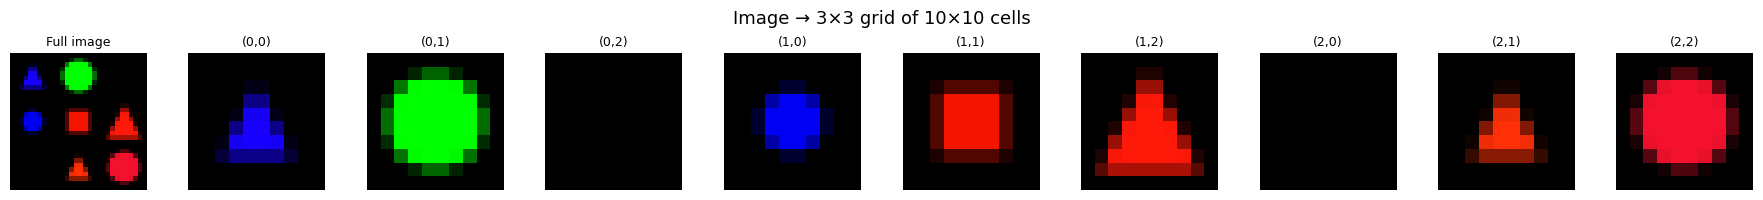

In [55]:
def extract_cells(image):
    # Split a 30x30 image into 9 cells of 10x10
    cells = []
    for row in range(3):
        for col in range(3):
            cell = image[row * 10:(row + 1) * 10, col * 10:(col + 1) * 10, :]
            cells.append(cell)
    return cells


# Example
sample_img = train_imgs_large[0]
sample_cells = extract_cells(sample_img)

fig, axes = plt.subplots(1, 10, figsize=(18, 2))
axes[0].imshow(sample_img)
axes[0].set_title('Full image', fontsize=9)
axes[0].axis('off')

for i in range(9):
    axes[i + 1].imshow(sample_cells[i])
    r, c = divmod(i, 3)
    axes[i + 1].set_title(f'({r},{c})', fontsize=9)
    axes[i + 1].axis('off')

fig.suptitle('Image → 3×3 grid of 10×10 cells', fontsize=13)
plt.tight_layout()
plt.show()

Although we have the images required to train the CNN, we lack their corresponding labels needed to train.
We approach this problem by heuristically labelling the shapes based on geometrical patterns. This doesn't guarantee full correctness but it is enough for a simple CNN like ours, if we train the CNN over all the cells produced from the splits. Labelling the colors is trivial.

In [56]:
def label_cell(cell):
    """
    Classify a 10x10x3 cell by colour and shape using pixel analysis.
    Returns (shape, colour) or (none, none) for empty cells.
    
    Logic:
    - mask = pixels where sum(RGB) > 10
    - colour: argmax of mean RGB over masked pixels
    - shape: row-width profile analysis
        triangle: monotonically non-decreasing widths with range > 1
        square:   fill_ratio >= 0.90
        circle:   everything else
    """
    mask = cell.sum(axis=2) > 10
    n_pixels = int(mask.sum())
    if n_pixels < 5:
        return None, None

    # Colour: dominant RGB channel
    mean_rgb = cell[mask].astype(np.float32).mean(axis=0)
    color = COLORS[int(np.argmax(mean_rgb))]

    # Shape: row-width profile analysis
    row_widths = [int(mask[r].sum()) for r in range(10) if mask[r].sum() > 0]
    if len(row_widths) < 2:
        return None, None

    widths = np.array(row_widths)

    if np.all(np.diff(widths) >= 0) and widths.max() - widths.min() > 1:
        return 'triangle', color

    fill_ratio = n_pixels / (len(widths) * int(widths.max()))
    if fill_ratio >= 0.90:
        return 'square', color

    return 'circle', color


def auto_label_cells(images):
    all_cells, all_shapes, all_colors = [], [], []
    for img in images:
        for cell in extract_cells(img):
            shape, color = label_cell(cell)
            if shape is not None:
                all_cells.append(cell)
                all_shapes.append(SHAPE_TO_IDX[shape])
                all_colors.append(COLOR_TO_IDX[color])
    return np.array(all_cells), np.array(all_shapes), np.array(all_colors)

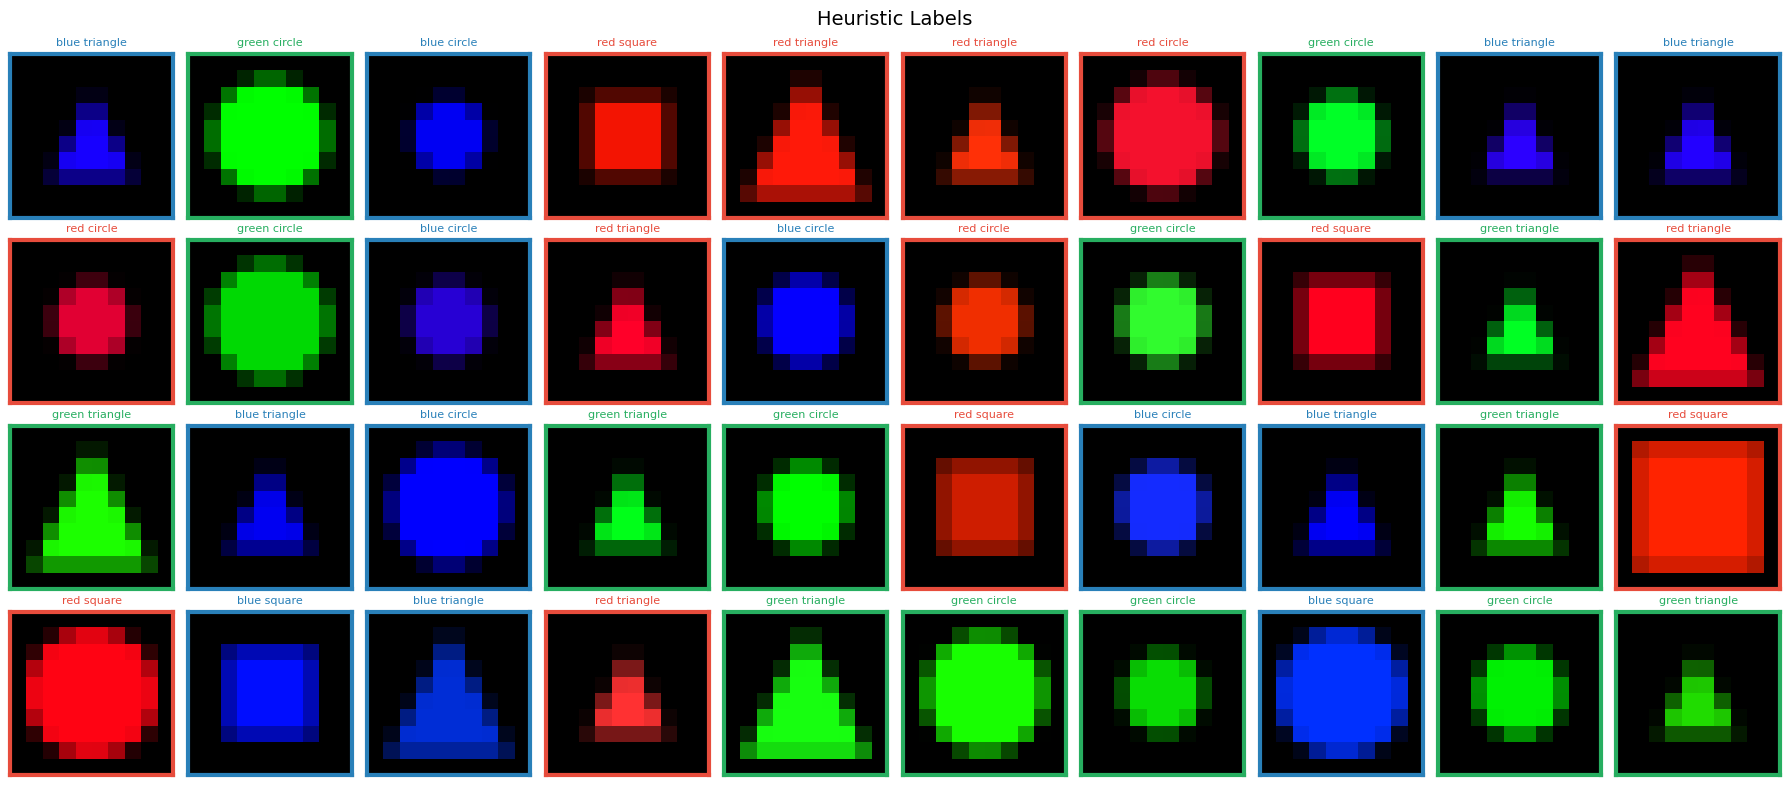

Shape distribution: {'circle': 39, 'square': 47, 'triangle': 55}
Color distribution: {'red': 42, 'green': 49, 'blue': 50}


In [57]:
# Visualise Labels
vis_cells, vis_shapes, vis_colors = auto_label_cells(train_imgs_large[:20])
n_show = min(40, len(vis_cells))

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
color_map = {'red': '#e74c3c', 'green': '#27ae60', 'blue': '#2980b9'}

for i in range(n_show):
    ax = axes[i // 10, i % 10]
    ax.imshow(vis_cells[i])
    s_name = SHAPES[vis_shapes[i]]
    c_name = COLORS[vis_colors[i]]
    ax.set_title(f'{c_name} {s_name}', fontsize=8, color=color_map[c_name])
    for spine in ax.spines.values():
        spine.set_edgecolor(color_map[c_name])
        spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

for i in range(n_show, 40):
    axes[i // 10, i % 10].axis('off')

fig.suptitle('Heuristic Labels', fontsize=14)
plt.tight_layout()
plt.show()

# Distribution
print("Shape distribution:", {s: int((vis_shapes == i).sum()) for i, s in enumerate(SHAPES)})
print("Color distribution:", {c: int((vis_colors == i).sum()) for i, c in enumerate(COLORS)})

In [58]:
class CellClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.shape_head = nn.Linear(64, len(SHAPES))
        self.color_head = nn.Linear(64, len(COLORS))

    def forward(self, x):
        feat = self.features(x).view(x.size(0), -1)
        return self.shape_head(feat), self.color_head(feat)


class CellDataset(Dataset):
    def __init__(self, cells, shapes, colors):
        self.cells = torch.from_numpy(cells).permute(0, 3, 1, 2).float() / 255.0
        self.shapes = torch.from_numpy(shapes).long()
        self.colors = torch.from_numpy(colors).long()

    def __len__(self):
        return len(self.cells)

    def __getitem__(self, idx):
        return self.cells[idx], self.shapes[idx], self.colors[idx]


print("CellClassifier Architecture:")
print(CellClassifier())

CellClassifier Architecture:
CellClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool2d(output_size=1)
  )
  (shape_head): Linear(in_features=64, out_features=3, bias=True)
  (color_head): Linear(in_features=64, out_features=3, bias=True)
)


In [59]:
# Train CNN
def train_cnn(cells, shapes, colors, epochs=30, batch_size=256, lr=1e-3, verbose=True):
    dataset = CellDataset(cells, shapes, colors)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = CellClassifier().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'loss': [], 'shape_acc': [], 'color_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = correct_s = correct_c = total = 0
        for bx, bs, bc in loader:
            bx, bs, bc = bx.to(DEVICE), bs.to(DEVICE), bc.to(DEVICE)
            sl, cl = model(bx)
            loss = criterion(sl, bs) + criterion(cl, bc)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * bx.size(0)
            correct_s += (sl.argmax(1) == bs).sum().item()
            correct_c += (cl.argmax(1) == bc).sum().item()
            total += bx.size(0)

        history['loss'].append(total_loss / total)
        history['shape_acc'].append(correct_s / total)
        history['color_acc'].append(correct_c / total)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  Epoch {epoch:>2}/{epochs}  Loss {history['loss'][-1]:.4f}  "
                  f"Shape {history['shape_acc'][-1]:.4f}  Color {history['color_acc'][-1]:.4f}")

    model.eval()
    return model, history


def plot_training_history(history, title='CNN Training'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['loss']) + 1)

    ax1.plot(epochs, history['loss'], 'b-')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['shape_acc'], 'g-', label='Shape Acc')
    ax2.plot(epochs, history['color_acc'], 'r-', label='Color Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

In [60]:
def perceive_image(model, image):
    cells = extract_cells(image)
    non_empty, positions = [], []
    for idx, cell in enumerate(cells):
        if cell.sum(axis=2).max() > 10:
            non_empty.append(cell)
            row, col = divmod(idx, 3)
            positions.append((col, row))  # x=col, y=row
    if not non_empty:
        return []
    batch = (torch.from_numpy(np.array(non_empty)).permute(0, 3, 1, 2).float() / 255.0).to(DEVICE)
    with torch.no_grad():
        sl, cl = model(batch)
        sp = sl.argmax(1).cpu().numpy()
        cp = cl.argmax(1).cpu().numpy()
    return [{'shape': SHAPES[sp[i]], 'color': COLORS[cp[i]],
            'x': positions[i][0], 'y': positions[i][1]}
            for i in range(len(non_empty))]

In [61]:
def tokenize(query):
    tokens, i = [], 0
    while i < len(query):
        ch = query[i]
        if ch in '()':
            tokens.append(ch); i += 1
        elif ch.isspace():
            i += 1
        else:
            j = i
            while j < len(query) and query[j] not in '() \t\n':
                j += 1
            tokens.append(query[i:j]); i = j
    return tokens


def _parse(tokens, pos):
    if tokens[pos] == '(':
        pos += 1
        op = tokens[pos]; pos += 1
        args = []
        while tokens[pos] != ')':
            arg, pos = _parse(tokens, pos)
            args.append(arg)
        return (op, *args), pos + 1
    return tokens[pos], pos + 1


def parse_query(query_str):
    tree, _ = _parse(tokenize(query_str.strip()), 0)
    return tree


# example
demo_queries = [
    "(is blue (left_of red))",
    "(is green (right_of (above square)))",
    "(is blue (left_of (right_of square)))",
]
for q in demo_queries:
    print(f"  {q}")
    print(f"    → {parse_query(q)}\n")

  (is blue (left_of red))
    → ('is', 'blue', ('left_of', 'red'))

  (is green (right_of (above square)))
    → ('is', 'green', ('right_of', ('above', 'square')))

  (is blue (left_of (right_of square)))
    → ('is', 'blue', ('left_of', ('right_of', 'square')))



In [62]:
def execute(tree, objects):
    if isinstance(tree, str):
        return {i for i, o in enumerate(objects)
                if o['color'] == tree or o['shape'] == tree}

    op = tree[0]

    if op == 'is':
        attr = tree[1]
        result_set = execute(tree[2], objects)
        return any(objects[i]['color'] == attr or objects[i]['shape'] == attr
                for i in result_set)

    inner = execute(tree[1], objects)
    if not inner:
        return set()

    if op == 'left_of':
        return {i for i in range(len(objects))
                if any(objects[i]['x'] < objects[j]['x'] for j in inner)}
    if op == 'right_of':
        return {i for i in range(len(objects))
                if any(objects[i]['x'] > objects[j]['x'] for j in inner)}
    if op == 'above':
        return {i for i in range(len(objects))
                if any(objects[i]['y'] < objects[j]['y'] for j in inner)}
    if op == 'below':
        return {i for i in range(len(objects))
                if any(objects[i]['y'] > objects[j]['y'] for j in inner)}


# Quick demo
demo_objects = [
    {'shape': 'circle', 'color': 'blue', 'x': 0, 'y': 0},
    {'shape': 'square', 'color': 'red',  'x': 2, 'y': 1},
    {'shape': 'triangle', 'color': 'green', 'x': 1, 'y': 2},
]
demo_tree = parse_query("(is blue (left_of red))")
print(f"Query:   (is blue (left_of red))")
print(f"Objects: {demo_objects}")
print(f"Result:  {execute(demo_tree, demo_objects)}")

Query:   (is blue (left_of red))
Objects: [{'shape': 'circle', 'color': 'blue', 'x': 0, 'y': 0}, {'shape': 'square', 'color': 'red', 'x': 2, 'y': 1}, {'shape': 'triangle', 'color': 'green', 'x': 1, 'y': 2}]
Result:  True


In [63]:
def _build_cell_data(images):
    # Pre-compute per-image cell info with heuristic labels.
    all_cells, all_shapes, all_colors = [], [], []
    image_cell_info = []
    for img in images:
        cells = extract_cells(img)
        img_cells = []
        for idx, cell in enumerate(cells):
            shape, color = label_cell(cell)
            if shape is not None:
                gi = len(all_cells)
                row, col = divmod(idx, 3)
                all_cells.append(cell)
                all_shapes.append(SHAPE_TO_IDX[shape])
                all_colors.append(COLOR_TO_IDX[color])
                img_cells.append({'color': color, 'x': col, 'y': row, 'gi': gi})
        image_cell_info.append(img_cells)
    return (np.array(all_cells), np.array(all_shapes), np.array(all_colors),
            image_cell_info)

In [64]:
def evaluate(model, images, queries, labels=None, desc='Evaluating'):
    predictions, correct = [], 0
    for i in tqdm(range(len(images)), desc=desc, leave=False):
        objs = perceive_image(model, images[i])
        pred = bool(execute(parse_query(queries[i]), objs))
        predictions.append(pred)
        if labels is not None and pred == labels[i]:
            correct += 1
    acc = correct / len(images) if labels is not None else None
    return predictions, acc

---
## Section 4 — Results Across All 4 Dataset Sizes

Now we run the full hybrid pipeline on every training split. For each size
we:
1. Generate heuristic cell labels
2. Train a CNN directly on those heuristic labels
3. Evaluate on the shared 1024-image test set

We shall also observe how does test accuracy scale with training set size?
More training data means more cells to learn from, which should improve
the perception stage and overall VQA performance.


  Size: TINY
  Images: 64
  Non-empty cells: 465
  Shapes: {'circle': 119, 'square': 180, 'triangle': 166}
  Colors: {'red': 130, 'green': 169, 'blue': 166}

  CNN training on heuristic labels (30 epochs):
  Epoch  1/30  Loss 2.0673  Shape 0.2559  Color 0.6194
  Epoch  5/30  Loss 1.2223  Shape 0.5355  Color 1.0000
  Epoch 10/30  Loss 0.9954  Shape 0.6409  Color 1.0000
  Epoch 15/30  Loss 0.8461  Shape 0.7054  Color 1.0000
  Epoch 20/30  Loss 0.7247  Shape 0.7677  Color 1.0000
  Epoch 25/30  Loss 0.6242  Shape 0.7892  Color 1.0000
  Epoch 30/30  Loss 0.5340  Shape 0.8409  Color 1.0000


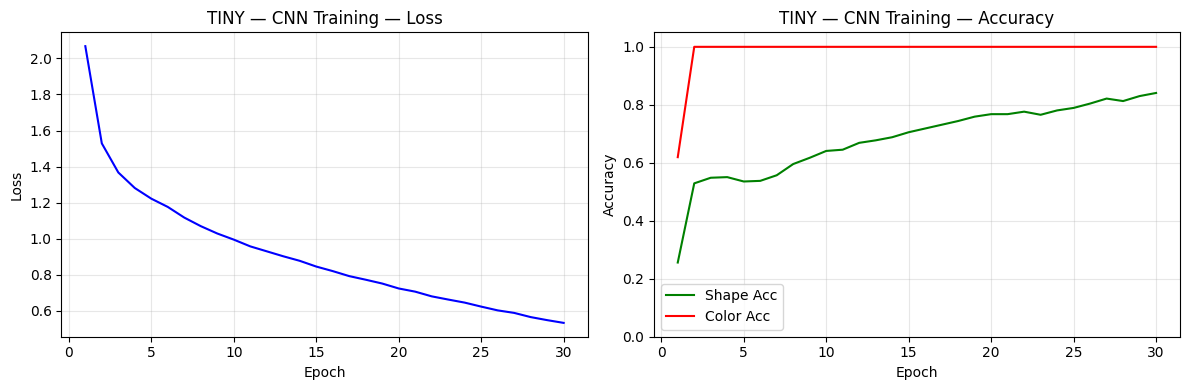


  Test accuracy: 0.8730 (894/1024)

  Size: SMALL
  Images: 640
  Non-empty cells: 4665
  Shapes: {'circle': 1210, 'square': 1905, 'triangle': 1550}
  Colors: {'red': 1517, 'green': 1565, 'blue': 1583}

  CNN training on heuristic labels (30 epochs):
  Epoch  1/30  Loss 1.3464  Shape 0.5372  Color 0.9318
  Epoch  5/30  Loss 0.4169  Shape 0.8924  Color 1.0000
  Epoch 10/30  Loss 0.1480  Shape 0.9593  Color 1.0000
  Epoch 15/30  Loss 0.0847  Shape 0.9760  Color 1.0000
  Epoch 20/30  Loss 0.0601  Shape 0.9831  Color 1.0000
  Epoch 25/30  Loss 0.0514  Shape 0.9826  Color 1.0000
  Epoch 30/30  Loss 0.0545  Shape 0.9814  Color 1.0000


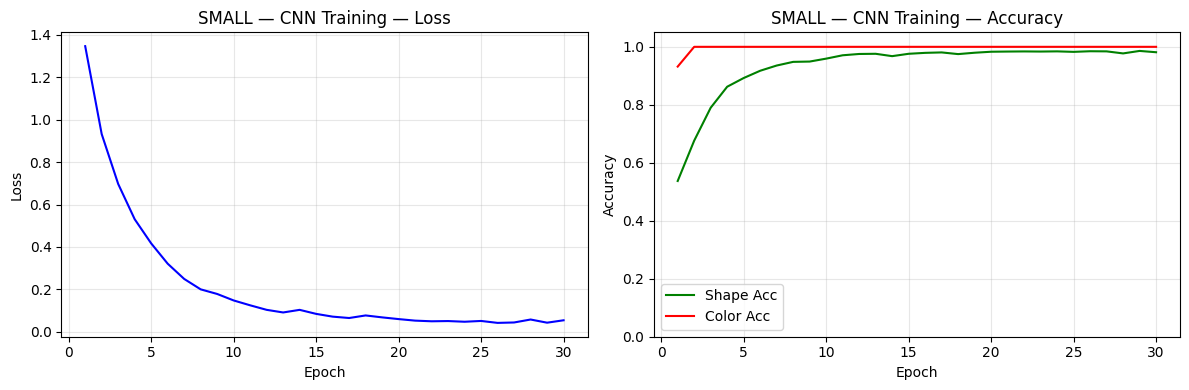


  Test accuracy: 0.9326 (955/1024)

  Size: MED
  Images: 6400
  Non-empty cells: 46379
  Shapes: {'circle': 12643, 'square': 18337, 'triangle': 15399}
  Colors: {'red': 15373, 'green': 15526, 'blue': 15480}

  CNN training on heuristic labels (30 epochs):
  Epoch  1/30  Loss 0.4658  Shape 0.8639  Color 0.9968
  Epoch  5/30  Loss 0.0237  Shape 0.9916  Color 1.0000
  Epoch 10/30  Loss 0.0152  Shape 0.9940  Color 1.0000
  Epoch 15/30  Loss 0.0128  Shape 0.9947  Color 1.0000
  Epoch 20/30  Loss 0.0103  Shape 0.9959  Color 1.0000
  Epoch 25/30  Loss 0.0108  Shape 0.9956  Color 1.0000
  Epoch 30/30  Loss 0.0093  Shape 0.9961  Color 1.0000


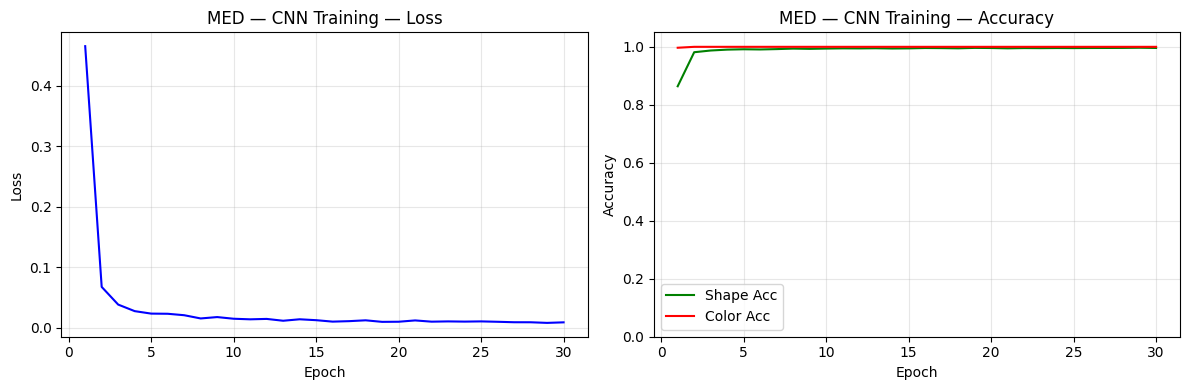


  Test accuracy: 0.9141 (936/1024)

  Size: LARGE
  Images: 13568
  Non-empty cells: 98172
  Shapes: {'circle': 26576, 'square': 38869, 'triangle': 32727}
  Colors: {'red': 32699, 'green': 32839, 'blue': 32634}

  CNN training on heuristic labels (30 epochs):
  Epoch  1/30  Loss 0.2700  Shape 0.9185  Color 0.9982
  Epoch  5/30  Loss 0.0166  Shape 0.9936  Color 1.0000
  Epoch 10/30  Loss 0.0106  Shape 0.9954  Color 1.0000
  Epoch 15/30  Loss 0.0106  Shape 0.9955  Color 1.0000
  Epoch 20/30  Loss 0.0084  Shape 0.9965  Color 1.0000
  Epoch 25/30  Loss 0.0073  Shape 0.9970  Color 1.0000
  Epoch 30/30  Loss 0.0070  Shape 0.9971  Color 1.0000


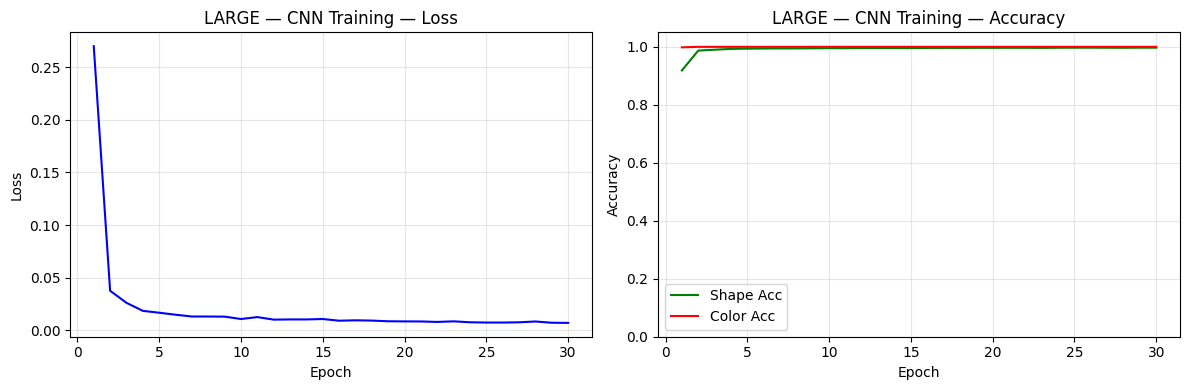


  Test accuracy: 0.9268 (949/1024)

  All sizes complete!


In [65]:
all_results = {}

for sz in SIZES:
    print(f"\n{'='*60}")
    print(f"  Size: {sz.upper()}")
    print(f"{'='*60}")

    # 1. Load data
    imgs, queries, labels = load_split(sz)
    print(f"  Images: {len(imgs)}")

    # 2. Heuristic label cells
    cells, shapes, colors, ici = _build_cell_data(imgs)
    print(f"  Non-empty cells: {len(cells)}")
    print(f"  Shapes: { {s: int((shapes==i).sum()) for i,s in enumerate(SHAPES)} }")
    print(f"  Colors: { {c: int((colors==i).sum()) for i,c in enumerate(COLORS)} }")
    # 3. CNN training directly on heuristic labels
    print(f"\n  CNN training on heuristic labels (30 epochs):")
    model, history = train_cnn(cells, shapes, colors, epochs=30, batch_size=256)

    # 4. Plot training history
    plot_training_history(history, title=f'{sz.upper()} — CNN Training')

    # 5. Evaluate on test set
    test_preds, test_acc = evaluate(model, test_images, test_queries,
                                   test_labels, desc=f'{sz} test')
    print(f"\n  Test accuracy: {test_acc:.4f} ({int(test_acc*len(test_images))}/{len(test_images)})")

    # Store results
    all_results[sz] = {
        'model': model,
        'history': history,
        'test_preds': test_preds,
        'test_acc': test_acc,
        'n_images': len(imgs),
        'n_cells': len(cells),
        'final_shape_acc': history['shape_acc'][-1],
        'final_color_acc': history['color_acc'][-1],
    }

print(f"\n{'='*60}")
print("  All sizes complete!")
print(f"{'='*60}")

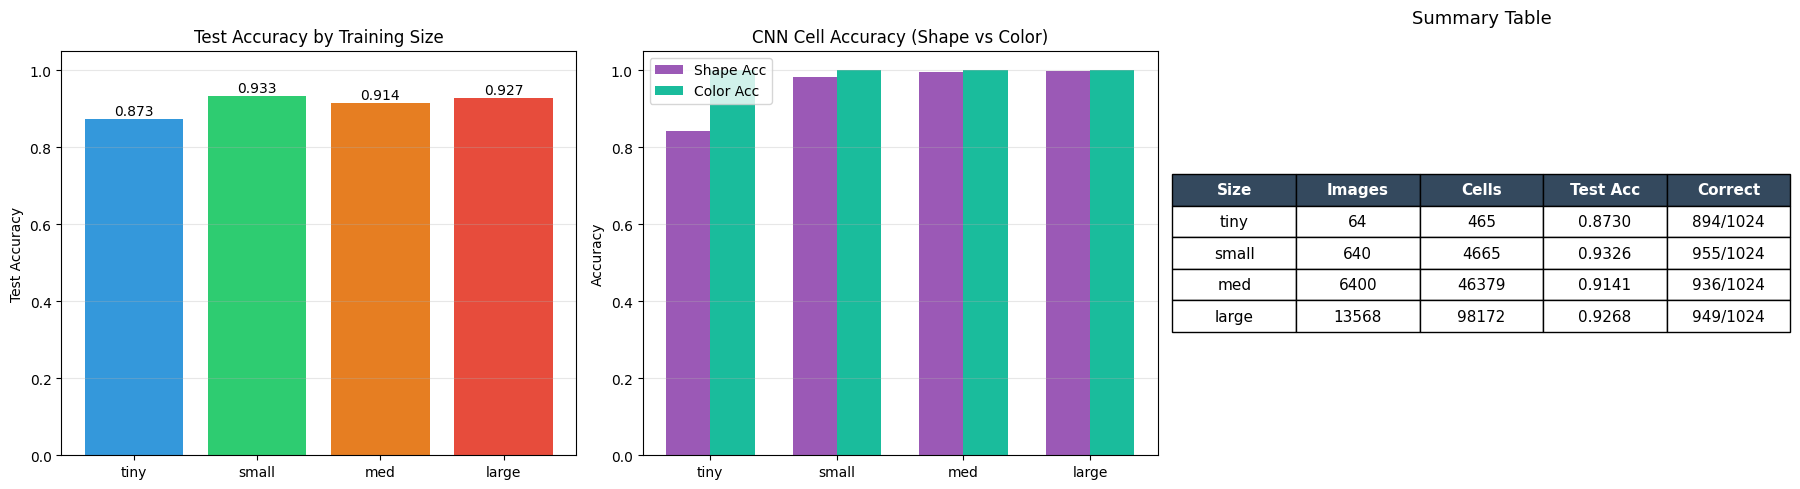

In [66]:
# Comparison charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: test accuracy per size
accs = [all_results[sz]['test_acc'] for sz in SIZES]
bars = axes[0].bar(SIZES, accs, color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'])
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Training Size')
axes[0].set_ylim(0, 1.05)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Grouped bar chart: shape acc + color acc per size
x = np.arange(len(SIZES))
w = 0.35
s_accs = [all_results[sz]['final_shape_acc'] for sz in SIZES]
c_accs = [all_results[sz]['final_color_acc'] for sz in SIZES]
axes[1].bar(x - w/2, s_accs, w, label='Shape Acc', color='#9b59b6')
axes[1].bar(x + w/2, c_accs, w, label='Color Acc', color='#1abc9c')
axes[1].set_xticks(x); axes[1].set_xticklabels(SIZES)
axes[1].set_ylabel('Accuracy'); axes[1].set_title('CNN Cell Accuracy (Shape vs Color)')
axes[1].legend(); axes[1].set_ylim(0, 1.05); axes[1].grid(True, alpha=0.3, axis='y')

# Text summary table
axes[2].axis('off')
table_data = [['Size', 'Images', 'Cells', 'Test Acc', 'Correct']]
for sz in SIZES:
    r = all_results[sz]
    table_data.append([sz, str(r['n_images']), str(r['n_cells']),
                       f"{r['test_acc']:.4f}",
                       f"{int(r['test_acc']*len(test_images))}/{len(test_images)}"])
table = axes[2].table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 1.8)
# Header styling
for j in range(5):
    table[0, j].set_facecolor('#34495e')
    table[0, j].set_text_props(color='white', fontweight='bold')
axes[2].set_title('Summary Table', fontsize=13, pad=20)

plt.tight_layout()
plt.show()

---
## Section 5 — Detailed Metrics & Analysis

Since accuracy alone can be misleading, we shall compute precision, recall, F1, and confusion matrices for each
training size, then compare them side-by-side to understand where the pipeline
succeeds and where it still makes mistakes.

Metrics are computed with sklearn utilities for consistency and readability.

In [67]:
# ── Metrics Computation (sklearn) ─────────────────────
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def compute_metrics(predictions, labels):
    """Compute TP, FP, FN, TN, Precision, Recall, F1, Accuracy using sklearn."""
    preds = np.array(predictions, dtype=bool)
    labs  = np.array(labels, dtype=bool)

    # sklearn confusion_matrix format (binary): [[TN, FP], [FN, TP]]
    cm = confusion_matrix(labs, preds, labels=[False, True])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(labs, preds, zero_division=0)
    recall = recall_score(labs, preds, zero_division=0)
    f1 = f1_score(labs, preds, zero_division=0)
    accuracy = accuracy_score(labs, preds)

    return {
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'precision': float(precision), 'recall': float(recall),
        'f1': float(f1), 'accuracy': float(accuracy),
    }


all_metrics = {}
for sz in SIZES:
    m = compute_metrics(all_results[sz]['test_preds'], test_labels)
    all_metrics[sz] = m
    print(f"\n  {sz.upper()}:")
    print(f"    TP={m['TP']:>4}  FP={m['FP']:>4}  FN={m['FN']:>4}  TN={m['TN']:>4}")
    print(
        f"    Precision={m['precision']:.4f}  Recall={m['recall']:.4f}  "
        f"F1={m['f1']:.4f}  Accuracy={m['accuracy']:.4f}"
    )


  TINY:
    TP= 531  FP=  88  FN=  42  TN= 363
    Precision=0.8578  Recall=0.9267  F1=0.8909  Accuracy=0.8730

  SMALL:
    TP= 558  FP=  54  FN=  15  TN= 397
    Precision=0.9118  Recall=0.9738  F1=0.9418  Accuracy=0.9326

  MED:
    TP= 553  FP=  68  FN=  20  TN= 383
    Precision=0.8905  Recall=0.9651  F1=0.9263  Accuracy=0.9141

  LARGE:
    TP= 557  FP=  59  FN=  16  TN= 392
    Precision=0.9042  Recall=0.9721  F1=0.9369  Accuracy=0.9268


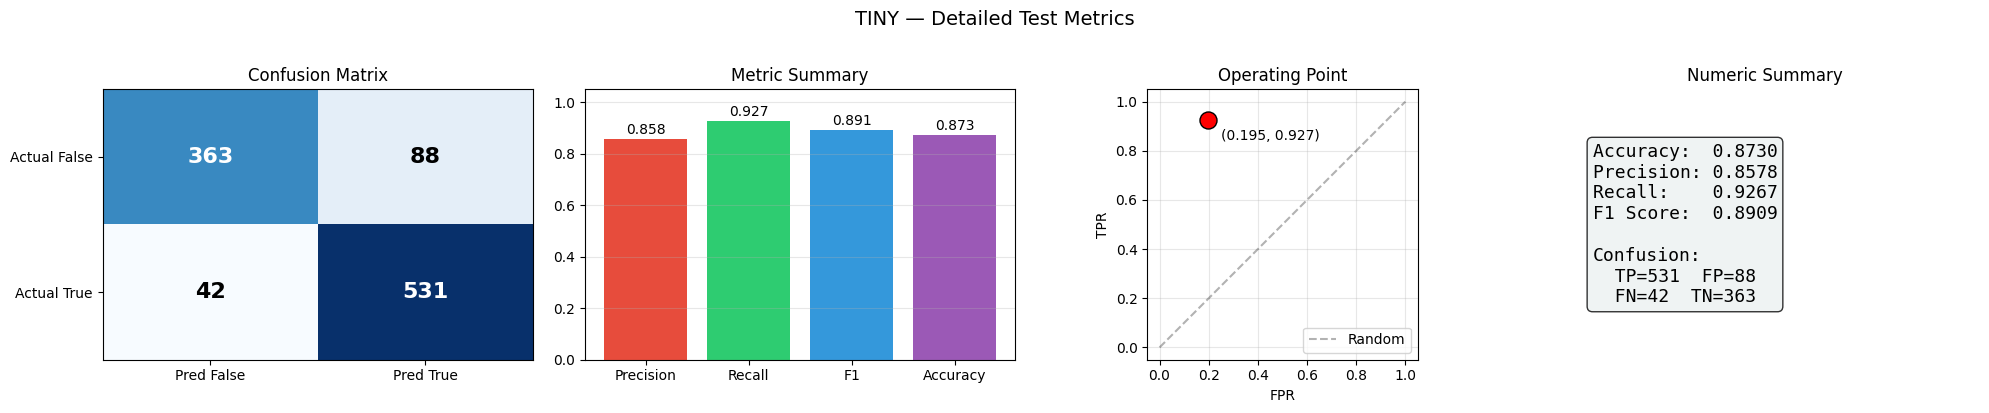

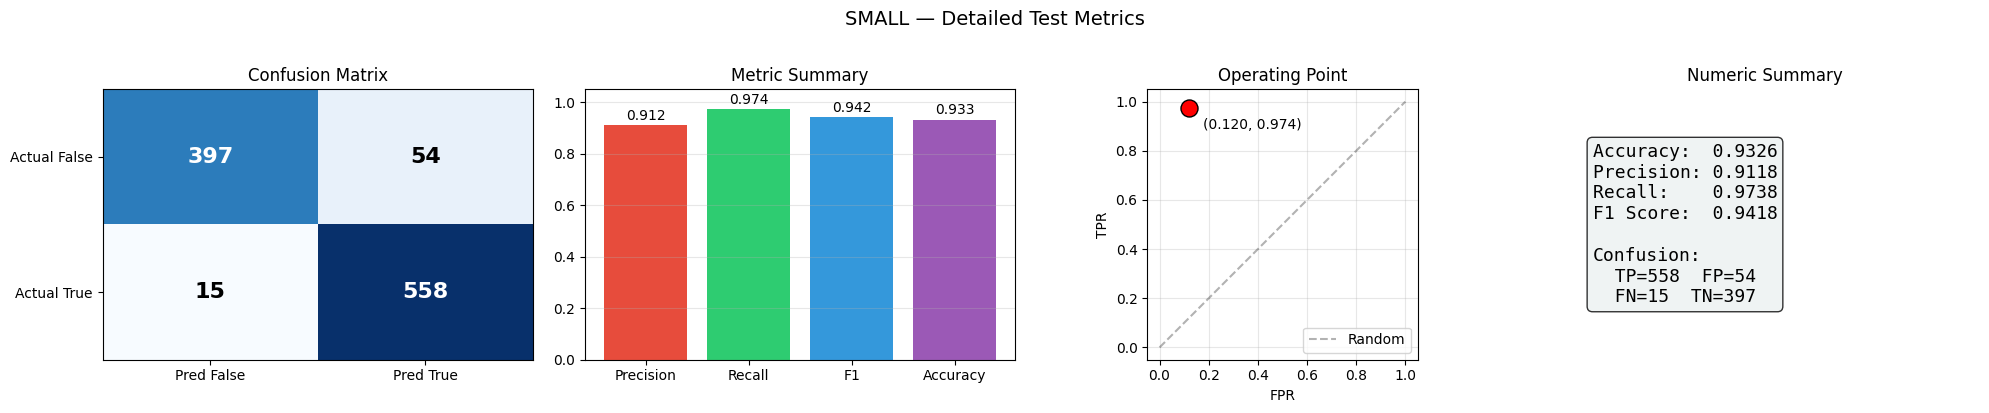

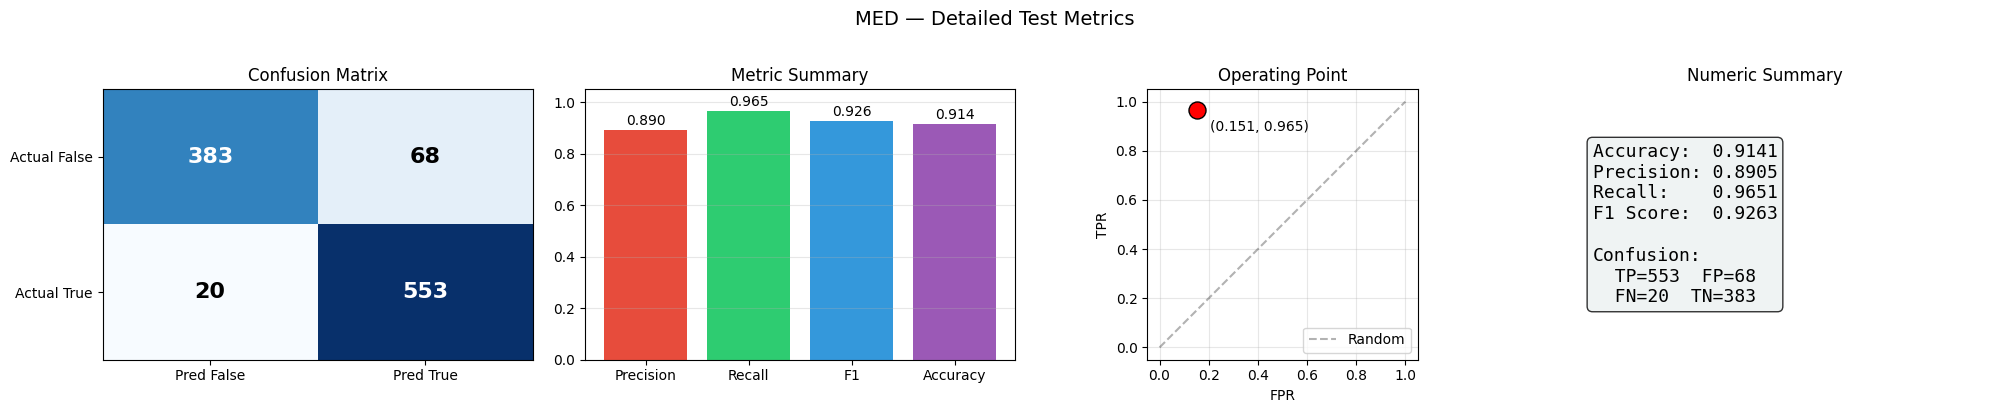

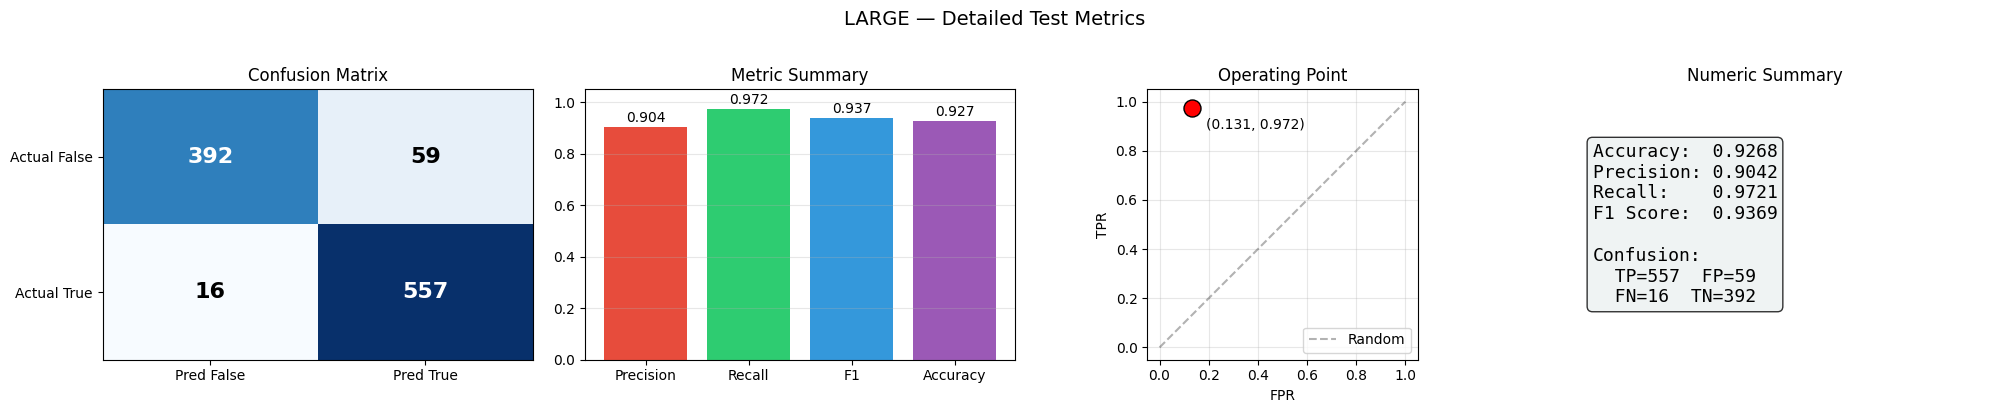

In [68]:
# ── Per-Size Detailed Figures ──────────────────────────
for sz in SIZES:
    m = all_metrics[sz]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'{sz.upper()} — Detailed Test Metrics', fontsize=14, y=1.02)

    # 1. Confusion matrix heatmap (rows=actual, cols=predicted)
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    im = axes[0].imshow(cm, cmap='Blues', aspect='auto')
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Pred False', 'Pred True'])
    axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Actual False', 'Actual True'])
    axes[0].set_title('Confusion Matrix')
    for (r, c), val in np.ndenumerate(cm):
        axes[0].text(c, r, str(val), ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if val > cm.max()/2 else 'black')

    # 2. Bar chart of Precision / Recall / F1 / Accuracy
    metric_names = ['Precision', 'Recall', 'F1', 'Accuracy']
    metric_vals = [m['precision'], m['recall'], m['f1'], m['accuracy']]
    bars = axes[1].bar(metric_names, metric_vals,
                       color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'])
    axes[1].set_ylim(0, 1.05); axes[1].set_title('Metric Summary')
    axes[1].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, metric_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontsize=10)

    # 3. Operating point on ROC unit square
    fpr = m['FP'] / (m['FP'] + m['TN'] + 1e-8)
    tpr = m['TP'] / (m['TP'] + m['FN'] + 1e-8)
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    axes[2].scatter([fpr], [tpr], s=150, c='red', zorder=5, edgecolors='black')
    axes[2].annotate(f'({fpr:.3f}, {tpr:.3f})', (fpr, tpr),
                     textcoords='offset points', xytext=(10, -15), fontsize=10)
    axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
    axes[2].set_title('Operating Point'); axes[2].set_xlim(-0.05, 1.05)
    axes[2].set_ylim(-0.05, 1.05); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    axes[2].set_aspect('equal')

    # 4. Text summary box
    axes[3].axis('off')
    summary_text = (
        f"Accuracy:  {m['accuracy']:.4f}\n"
        f"Precision: {m['precision']:.4f}\n"
        f"Recall:    {m['recall']:.4f}\n"
        f"F1 Score:  {m['f1']:.4f}\n"
        f"\nConfusion:\n"
        f"  TP={m['TP']}  FP={m['FP']}\n"
        f"  FN={m['FN']}  TN={m['TN']}"
    )
    axes[3].text(0.1, 0.5, summary_text, transform=axes[3].transAxes,
                 fontsize=13, verticalalignment='center', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    axes[3].set_title('Numeric Summary')

    plt.tight_layout()
    plt.show()

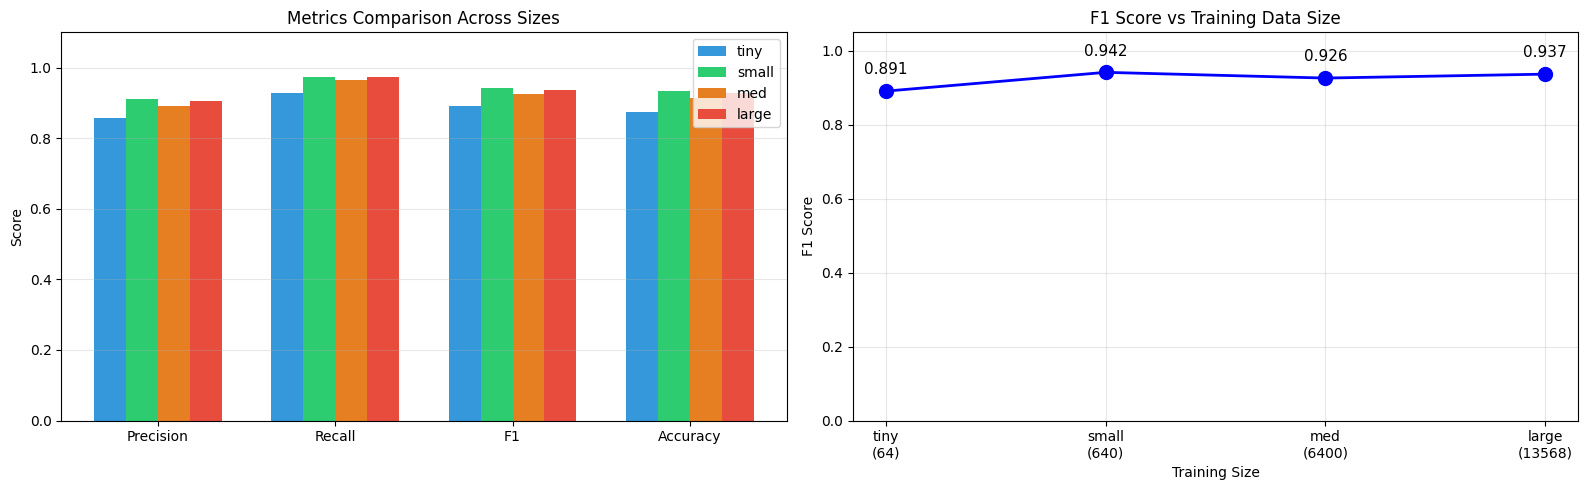

In [69]:
# ── Combined Comparison Across All Sizes ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Grouped bar chart: P, R, F1, Acc — one group per metric, one bar per size
metric_keys = ['precision', 'recall', 'f1', 'accuracy']
metric_labels = ['Precision', 'Recall', 'F1', 'Accuracy']
x = np.arange(len(metric_keys))
w = 0.18
size_colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for j, sz in enumerate(SIZES):
    vals = [all_metrics[sz][k] for k in metric_keys]
    ax1.bar(x + j * w, vals, w, label=sz, color=size_colors[j])

ax1.set_xticks(x + 1.5 * w)
ax1.set_xticklabels(metric_labels)
ax1.set_ylabel('Score'); ax1.set_title('Metrics Comparison Across Sizes')
ax1.legend(); ax1.set_ylim(0, 1.1); ax1.grid(True, alpha=0.3, axis='y')

# 2. Line plot: F1 vs dataset size
f1_scores = [all_metrics[sz]['f1'] for sz in SIZES]
n_images  = [all_results[sz]['n_images'] for sz in SIZES]
ax2.plot(range(len(SIZES)), f1_scores, 'bo-', markersize=10, linewidth=2)
ax2.set_xticks(range(len(SIZES)))
ax2.set_xticklabels([f'{sz}\n({n})' for sz, n in zip(SIZES, n_images)])
ax2.set_ylabel('F1 Score'); ax2.set_xlabel('Training Size')
ax2.set_title('F1 Score vs Training Data Size')
ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1.05)
for i, (sz, f1) in enumerate(zip(SIZES, f1_scores)):
    ax2.annotate(f'{f1:.3f}', (i, f1), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

---
## Section 6 — Save Outputs

We save the test predictions for every training size as well as the best
model's weights, so the results are fully reproducible and can be submitted
or evaluated offline.

In [70]:
# ── Save Predictions & Best Model ──────────────────────
# Find the best-performing size
best_size = max(SIZES, key=lambda sz: all_results[sz]['test_acc'])
print(f"Best performing size: {best_size} (test acc = {all_results[best_size]['test_acc']:.4f})\n")

# Save predictions for every size
for sz in SIZES:
    fname = f'predictions_{sz}.txt'
    with open(fname, 'w') as f:
        for p in all_results[sz]['test_preds']:
            f.write('true\n' if p else 'false\n')
    print(f"  Saved {fname}")

# Save best model
model_fname = f'cell_classifier_{best_size}.pth'
torch.save(all_results[best_size]['model'].state_dict(), model_fname)
print(f"  Saved {model_fname}")

print(f"\nDone! All outputs saved.")

Best performing size: small (test acc = 0.9326)

  Saved predictions_tiny.txt
  Saved predictions_small.txt
  Saved predictions_med.txt
  Saved predictions_large.txt
  Saved cell_classifier_small.pth

Done! All outputs saved.
